## 🌐 Understanding the XLM-RoBERTa Model

### What is XLM-RoBERTa?

**XLM-RoBERTa (XLM-R)** is a multilingual Transformer model developed by **Facebook AI (Meta)**. It is capable of understanding and representing text in **100 different languages** using a **single shared model** — eliminating the need to train separate models for each language.

**Name breakdown:**
- **XLM** → Cross-lingual Language Model  
- **RoBERTa** → Robustly Optimized BERT Approach

---

### 🔧 How It Works

**1. Shared Multilingual Vocabulary**  
XLM-R uses a single **SentencePiece tokenizer** with a vocabulary of ~250,000 subword tokens shared across all 100 languages — covering scripts like Latin, Devanagari, Cyrillic, Arabic, and Chinese.

**2. Pretraining Objective — Masked Language Modeling (MLM)**  
Like BERT, XLM-R is trained by masking random words and predicting them — but across a massive multilingual dataset called **CC-100** (~2.5TB of filtered CommonCrawl text spanning 100 languages).

**3. Cross-Lingual Transfer**  
Since all languages share one embedding space, the model learns that semantically similar words across different languages end up with similar internal representations — **even without direct translation pairs**. This is why a model fine-tuned on **English** sentiment data can still meaningfully classify **Hindi** or **Nepali** text.

---

### 🏗️ Model Architecture

| Component | XLM-R Base | XLM-R Large |
|---|---|---|
| Layers | 12 | 24 |
| Hidden Size | 768 | 1024 |
| Attention Heads | 12 | 16 |
| Parameters | ~270M | ~550M |
| Supported Languages | 100 | 100 |

The model used in this notebook — `cardiffnlp/twitter-xlm-roberta-base-sentiment` — is an **XLM-R Base** model, further fine-tuned on multilingual Twitter data labeled for sentiment (**negative / neutral / positive**).

---

### ✅ Why XLM-RoBERTa Is Used in This Project

1. **One model, many languages** — handles English, Hindi, Nepali, Spanish, French, and German without training separate models.
2. **Zero-shot / low-resource advantage** — performs reasonably well even on languages with limited labeled data (like Nepali), thanks to shared subword structure and cross-lingual semantic transfer.
3. **Easy deployment** — accessed via Hugging Face's `pipeline("sentiment-analysis", model=...)`, which handles tokenization, inference, and label mapping in one call.

---

### ⚠️ Limitation & Future Work

The sentiment checkpoint used here was **not explicitly fine-tuned on labeled Nepali data** — it performs via cross-lingual transfer from related Devanagari-script languages such as Hindi. Fine-tuning on a dedicated Nepali sentiment dataset would likely improve classification accuracy further and is a good direction for future work.

# Multilingual Sentiment Analysis using XLM-RoBERTa

### NLP Mini Project

#### Objectives

* Analyze sentiment in multiple languages.

* Use a pretrained multilingual transformer model.

* Classify text as Positive, Negative, or Neutral.

* Visualize the sentiment distribution.

* Compare sentiment predictions across languages.





#### Languages Used

* English

* Nepali

* Hindi

#### Model

cardiffnlp/twitter-xlm-roberta-base-sentiment

#### Explanation

This section introduces the project, its objectives, the languages analyzed, and the pretrained multilingual transformer model used for sentiment classification.

In [ ]:
!pip install -q transformers torch sentencepiece wordcloud pandas matplotlib seaborn nltk

#Installed Required Libraries

In [ ]:
#Import Libraries

import pandas as pd
import numpy as np
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from transformers import pipeline

import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
data = {
    "review": [
        # English
        "I absolutely love this product, it works perfectly!",
        "This is the worst purchase I have ever made.",
        "The quality is okay, nothing special.",
        "Amazing customer service and fast delivery.",
        "I am very disappointed with this item.",

        # Hindi
        "यह उत्पाद बहुत बढ़िया है, मुझे बहुत पसंद आया।",
        "यह बहुत ही खराब अनुभव था, बिल्कुल पसंद नहीं आया।",
        "ठीक ठाक है, कुछ खास नहीं।",
        "डिलीवरी बहुत तेज़ थी, धन्यवाद।",
        "मैं इस खरीदारी से निराश हूं।",

        # Nepali
        "यो सामान एकदम राम्रो छ, मलाई मन पर्यो।",
        "यो अनुभव धेरै नराम्रो थियो।",
        "ठिकै छ, विशेष केही छैन।",
        "छिटो डेलिभरी भयो, धन्यवाद।",
        "म यो खरिदबाट निराश छु।",

        # Spanish
        "Me encanta este producto, funciona perfectamente.",
        "Esta es la peor compra que he hecho.",
        "La calidad es aceptable, nada especial.",
        "Excelente servicio al cliente y entrega rápida.",
        "Estoy muy decepcionado con este artículo.",

        # French
        "J'adore ce produit, il fonctionne parfaitement.",
        "C'est le pire achat que j'ai jamais fait.",
        "La qualité est correcte, rien de spécial.",
        "Excellent service client et livraison rapide.",
        "Je suis très déçu de cet article.",

        # German
        "Ich liebe dieses Produkt, es funktioniert einwandfrei.",
        "Das ist der schlechteste Kauf, den ich je getätigt habe.",
        "Die Qualität ist okay, nichts Besonderes.",
        "Toller Kundenservice und schnelle Lieferung.",
        "Ich bin sehr enttäuscht von diesem Artikel."
    ],
    "language": [
        "English"]*5 + ["Hindi"]*5 + ["Nepali"]*5 + ["Spanish"]*5 + ["French"]*5 + ["German"]*5
}

df = pd.DataFrame(data)
df.head(10)

,review,language
0,"I absolutely love this product, it works perfe...",English
1,This is the worst purchase I have ever made.,English
2,"The quality is okay, nothing special.",English
3,Amazing customer service and fast delivery.,English
4,I am very disappointed with this item.,English
5,"यह उत्पाद बहुत बढ़िया है, मुझे बहुत पसंद आया।",Hindi
6,"यह बहुत ही खराब अनुभव था, बिल्कुल पसंद नहीं आया।",Hindi
7,"ठीक ठाक है, कुछ खास नहीं।",Hindi
8,"डिलीवरी बहुत तेज़ थी, धन्यवाद।",Hindi
9,मैं इस खरीदारी से निराश हूं।,Hindi


In [ ]:
print("Dataset shape:", df.shape)
print("\nLanguage distribution:")
print(df['language'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample reviews:")
df.sample(5, random_state=42)

Dataset shape: (30, 2)

Language distribution:
language
English    5
Hindi      5
Nepali     5
Spanish    5
French     5
German     5
Name: count, dtype: int64

Missing values:
review      0
language    0
dtype: int64

Sample reviews:


,review,language
27,"Die Qualität ist okay, nichts Besonderes.",German
15,"Me encanta este producto, funciona perfectamente.",Spanish
23,Excellent service client et livraison rapide.,French
17,"La calidad es aceptable, nada especial.",Spanish
8,"डिलीवरी बहुत तेज़ थी, धन्यवाद।",Hindi


In [ ]:
#Clean the Text
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'\d+', '', text)                  # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra whitespace
    return text

df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(10)

,review,clean_review
0,"I absolutely love this product, it works perfe...",I absolutely love this product it works perfectly
1,This is the worst purchase I have ever made.,This is the worst purchase I have ever made
2,"The quality is okay, nothing special.",The quality is okay nothing special
3,Amazing customer service and fast delivery.,Amazing customer service and fast delivery
4,I am very disappointed with this item.,I am very disappointed with this item
5,"यह उत्पाद बहुत बढ़िया है, मुझे बहुत पसंद आया।",यह उत्पाद बहुत बढ़िया है मुझे बहुत पसंद आया।
6,"यह बहुत ही खराब अनुभव था, बिल्कुल पसंद नहीं आया।",यह बहुत ही खराब अनुभव था बिल्कुल पसंद नहीं आया।
7,"ठीक ठाक है, कुछ खास नहीं।",ठीक ठाक है कुछ खास नहीं।
8,"डिलीवरी बहुत तेज़ थी, धन्यवाद।",डिलीवरी बहुत तेज़ थी धन्यवाद।
9,मैं इस खरीदारी से निराश हूं।,मैं इस खरीदारी से निराश हूं।


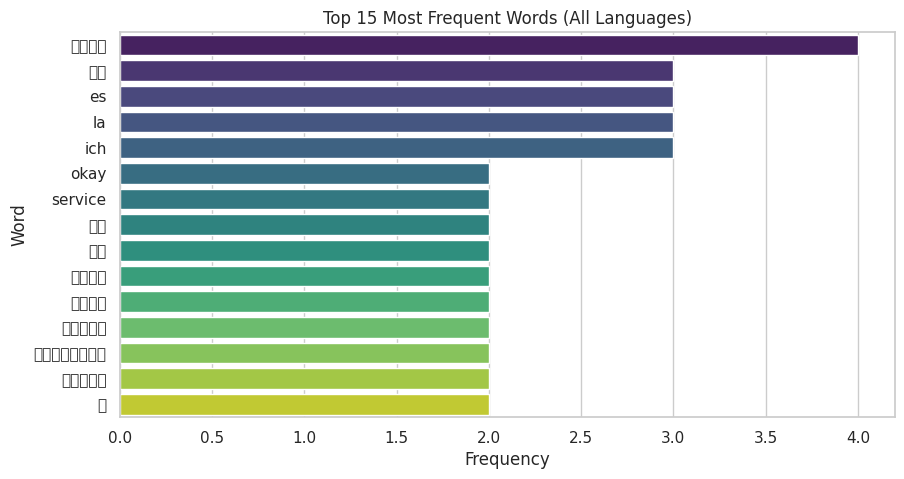

In [ ]:
#Display Word Frequencies
# Combine all cleaned text (English subset works best for word-level frequency,
# but here we tokenize everything by whitespace)
all_words = " ".join(df['clean_review']).lower().split()

# Optional: remove common English stopwords only (multilingual stopword removal is skipped for simplicity)
english_stopwords = set(stopwords.words('english'))
filtered_words = [w for w in all_words if w not in english_stopwords]

word_freq = Counter(filtered_words)
most_common = word_freq.most_common(15)

words, counts = zip(*most_common)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 15 Most Frequent Words (All Languages)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

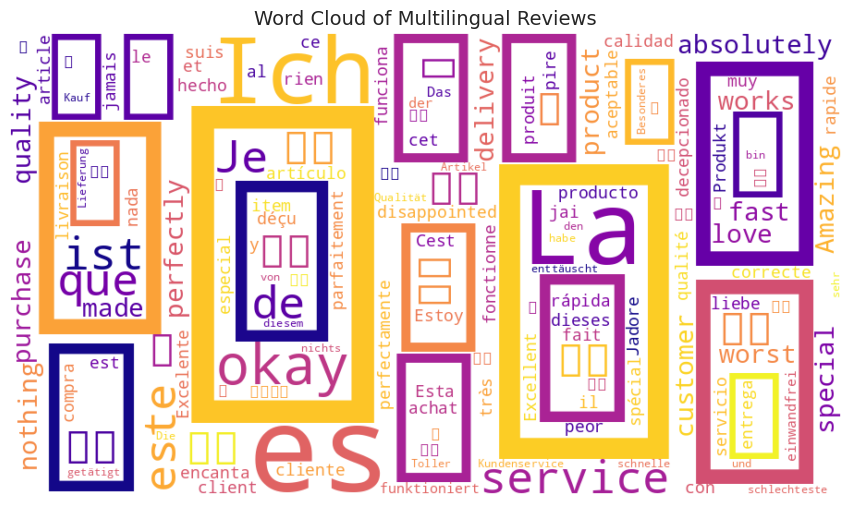

In [ ]:
#Generate a Word Cloud

text_for_cloud = " ".join(df['clean_review'])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    colormap="plasma",
    collocations=False
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Multilingual Reviews", fontsize=14)
plt.show()

In [ ]:
#Load the Multilingual Sentiment Model

# XLM-RoBERTa based multilingual sentiment model (supports 100+ languages)
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

# Quick test
print(sentiment_pipeline("I love this!"))
print(sentiment_pipeline("यह बहुत खराब है।"))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'positive', 'score': 0.9384338855743408}]
[{'label': 'negative', 'score': 0.9382690787315369}]


In [ ]:
#Predict Sentiment for All Reviews

def get_sentiment(text):
    result = sentiment_pipeline(text[:512])[0]  # truncate long text safely
    return result['label'], round(result['score'], 3)

df[['predicted_sentiment', 'confidence']] = df['clean_review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

# Map model labels to readable form (model outputs: negative / neutral / positive)
label_map = {
    "negative": "Negative",
    "neutral": "Neutral",
    "positive": "Positive"
}
df['predicted_sentiment'] = df['predicted_sentiment'].map(label_map)

df[['review', 'language', 'predicted_sentiment', 'confidence']].head(10)

,review,language,predicted_sentiment,confidence
0,"I absolutely love this product, it works perfe...",English,Positive,0.933
1,This is the worst purchase I have ever made.,English,Negative,0.943
2,"The quality is okay, nothing special.",English,Neutral,0.485
3,Amazing customer service and fast delivery.,English,Positive,0.815
4,I am very disappointed with this item.,English,Negative,0.954
5,"यह उत्पाद बहुत बढ़िया है, मुझे बहुत पसंद आया।",Hindi,Positive,0.905
6,"यह बहुत ही खराब अनुभव था, बिल्कुल पसंद नहीं आया।",Hindi,Negative,0.929
7,"ठीक ठाक है, कुछ खास नहीं।",Hindi,Negative,0.347
8,"डिलीवरी बहुत तेज़ थी, धन्यवाद।",Hindi,Positive,0.646
9,मैं इस खरीदारी से निराश हूं।,Hindi,Negative,0.946


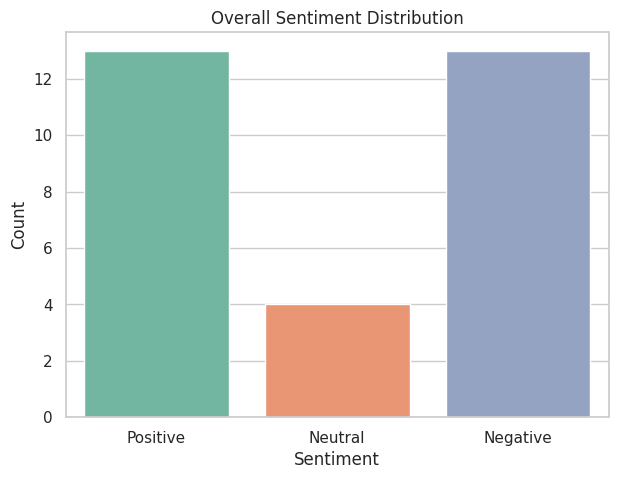

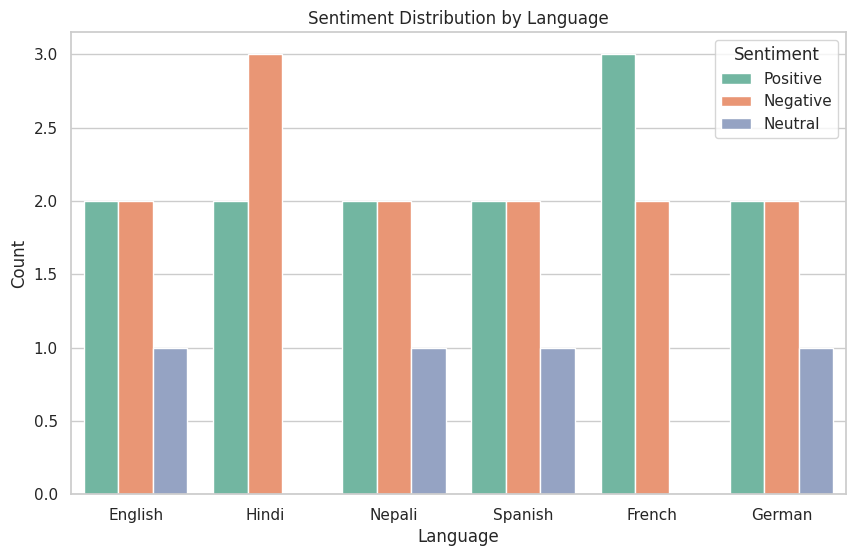

In [ ]:
#Sentiment Distribution

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='predicted_sentiment', order=['Positive', 'Neutral', 'Negative'], palette="Set2")
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='language', hue='predicted_sentiment', palette="Set2")
plt.title("Sentiment Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.show()

In [ ]:
#Test Custom Sentences

custom_sentences = [
    "This is the best day of my life!",                    # English - Positive
    "मुझे यह बिल्कुल पसंद नहीं आया।",                          # Hindi - Negative
    "यो सामान ठिकै थियो, खासै केही थिएन।",                     # Nepali - Neutral
    "No puedo creer lo increíble que es esto.",             # Spanish - Positive
    "C'est vraiment décevant.",                             # French - Negative
    "Das war eine völlig normale Erfahrung."                # German - Neutral
]

print(f"{'Sentence':<55} {'Sentiment':<10} {'Confidence'}")
print("-" * 80)
for sentence in custom_sentences:
    label, score = get_sentiment(sentence)
    print(f"{sentence[:53]:<55} {label_map[label]:<10} {score}")

Sentence                                                Sentiment  Confidence
--------------------------------------------------------------------------------
This is the best day of my life!                        Positive   0.94
मुझे यह बिल्कुल पसंद नहीं आया।                          Negative   0.777
यो सामान ठिकै थियो, खासै केही थिएन।                     Neutral    0.495
No puedo creer lo increíble que es esto.                Positive   0.755
C'est vraiment décevant.                                Negative   0.905
Das war eine völlig normale Erfahrung.                  Positive   0.618


In [ ]:
# Final Results Table

final_results = df[['review', 'language', 'predicted_sentiment', 'confidence']].copy()
final_results.columns = ['Review', 'Language', 'Sentiment', 'Confidence']
final_results = final_results.sort_values(by='Confidence', ascending=False).reset_index(drop=True)

final_results

,Review,Language,Sentiment,Confidence
0,Je suis très déçu de cet article.,French,Negative,0.966
1,C'est le pire achat que j'ai jamais fait.,French,Negative,0.961
2,I am very disappointed with this item.,English,Negative,0.954
3,Ich bin sehr enttäuscht von diesem Artikel.,German,Negative,0.952
4,"J'adore ce produit, il fonctionne parfaitement.",French,Positive,0.949
5,मैं इस खरीदारी से निराश हूं।,Hindi,Negative,0.946
6,Estoy muy decepcionado con este artículo.,Spanish,Negative,0.944
7,Esta es la peor compra que he hecho.,Spanish,Negative,0.944
8,This is the worst purchase I have ever made.,English,Negative,0.943
9,"Ich liebe dieses Produkt, es funktioniert einw...",German,Positive,0.941


In [ ]:
#Conclusion

total = len(df)
pos = (df['predicted_sentiment'] == 'Positive').sum()
neg = (df['predicted_sentiment'] == 'Negative').sum()
neu = (df['predicted_sentiment'] == 'Neutral').sum()

print("=" * 60)
print("CONCLUSION")
print("=" * 60)
print(f"Total reviews analyzed: {total}")
print(f"Positive: {pos} ({pos/total*100:.1f}%)")
print(f"Negative: {neg} ({neg/total*100:.1f}%)")
print(f"Neutral:  {neu} ({neu/total*100:.1f}%)")
print("\nThe XLM-RoBERTa multilingual sentiment model successfully classified")
print("reviews across English, Hindi, Nepali, Spanish, French, and German")
print("without requiring separate models per language, demonstrating the")
print("power of cross-lingual transfer learning for sentiment analysis.")

CONCLUSION
Total reviews analyzed: 30
Positive: 13 (43.3%)
Negative: 13 (43.3%)
Neutral:  4 (13.3%)

The XLM-RoBERTa multilingual sentiment model successfully classified
reviews across English, Hindi, Nepali, Spanish, French, and German
without requiring separate models per language, demonstrating the
power of cross-lingual transfer learning for sentiment analysis.


In [ ]:

print("\n" + "=" * 60)
print("MANUAL SENTENCE INPUT")
print("=" * 60)

user_sentence = input("Please enter a sentence to analyze: ")

if user_sentence:
    label, score = get_sentiment(user_sentence)
    print(f"\nSentence: {user_sentence}")
    print(f"Predicted Sentiment: {label_map[label]} (Confidence: {score:.3f})")
else:
    print("No sentence was entered.")


MANUAL SENTENCE INPUT
Please enter a sentence to analyze: ## 🌐 Understanding the XLM-RoBERTa Model  ### What is XLM-RoBERTa?  **XLM-RoBERTa (XLM-R)** is a multilingual Transformer model developed by **Facebook AI (Meta)**. It is capable of understanding and representing text in **100 different languages** using a **single shared model** — eliminating the need to train separate models for each language.  **Name breakdown:** - **XLM** → Cross-lingual Language Model   - **RoBERTa** → Robustly Optimized BERT Approach  ---  ### 🔧 How It Works  **1. Shared Multilingual Vocabulary**   XLM-R uses a single **SentencePiece tokenizer** with a vocabulary of ~250,000 subword tokens shared across all 100 languages — covering scripts like Latin, Devanagari, Cyrillic, Arabic, and Chinese.  **2. Pretraining Objective — Masked Language Modeling (MLM)**   Like BERT, XLM-R is trained by masking random words and predicting them — but across a massive multilingual dataset called **CC-100** (~2.5TB of filte